In [2]:
# Install and import libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import hog
from skimage import exposure
import seaborn as sns
from tqdm import tqdm

print("Libraries imported successfully!")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Libraries imported successfully!
Using device: cuda


In [3]:
# Download GTSRB dataset
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Download training set
train_dataset_full = datasets.GTSRB(
    root='./data',
    split='train',
    transform=transform,
    download=True
)

# Download test set
test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    transform=transform,
    download=True
)

# Split training into train and validation
train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 187M/187M [00:15<00:00, 11.8MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.86MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 211kB/s]


Training samples: 23976
Validation samples: 2664
Test samples: 12630


In [4]:
# Extract HOG features from dataset
def extract_hog_features(dataset):
    features = []
    labels = []

    print("Extracting HOG features...")
    for i in tqdm(range(len(dataset))):
        image, label = dataset[i]
        # Convert tensor to numpy (C, H, W) -> (H, W, C)
        image_np = image.permute(1, 2, 0).numpy()

        # Extract HOG features
        hog_features = hog(
            image_np,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            channel_axis=-1
        )

        features.append(hog_features)
        labels.append(label)

    return np.array(features), np.array(labels)

# Extract features for train and test
print("Processing training set...")
X_train, y_train = extract_hog_features(train_dataset)

print("Processing test set...")
X_test, y_test = extract_hog_features(test_dataset)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print("HOG feature extraction complete!")


Processing training set...
Extracting HOG features...


100%|██████████| 23976/23976 [00:59<00:00, 404.21it/s]


Processing test set...
Extracting HOG features...


100%|██████████| 12630/12630 [00:30<00:00, 419.27it/s]


Training features shape: (23976, 1764)
Test features shape: (12630, 1764)
HOG feature extraction complete!


In [5]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# Scale features
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LinearSVC (faster than SVC for large datasets)
print("Training HOG + LinearSVM classifier...")
print("This may take a few minutes...")

svm_model = LinearSVC(
    C=0.1,
    max_iter=2000,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
print("Training complete!")

# Evaluate on test set
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nHOG + SVM Test Accuracy: {accuracy * 100:.2f}%")


Scaling features...
Training HOG + LinearSVM classifier...
This may take a few minutes...
Training complete!

HOG + SVM Test Accuracy: 87.17%


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.70      0.67        60
           1       0.84      0.83      0.84       720
           2       0.78      0.84      0.81       750
           3       0.80      0.74      0.77       450
           4       0.91      0.90      0.90       660
           5       0.69      0.78      0.73       630
           6       0.85      0.81      0.83       150
           7       0.83      0.81      0.82       450
           8       0.82      0.78      0.80       450
           9       0.89      0.96      0.92       480
          10       0.93      0.94      0.94       660
          11       0.80      0.77      0.79       420
          12       0.98      0.98      0.98       690
          13       0.99      1.00      0.99       720
          14       0.98      0.97      0.97       270
          15       0.94      0.96      0.95       210
          16       0.96      0.97      0.96       150
    

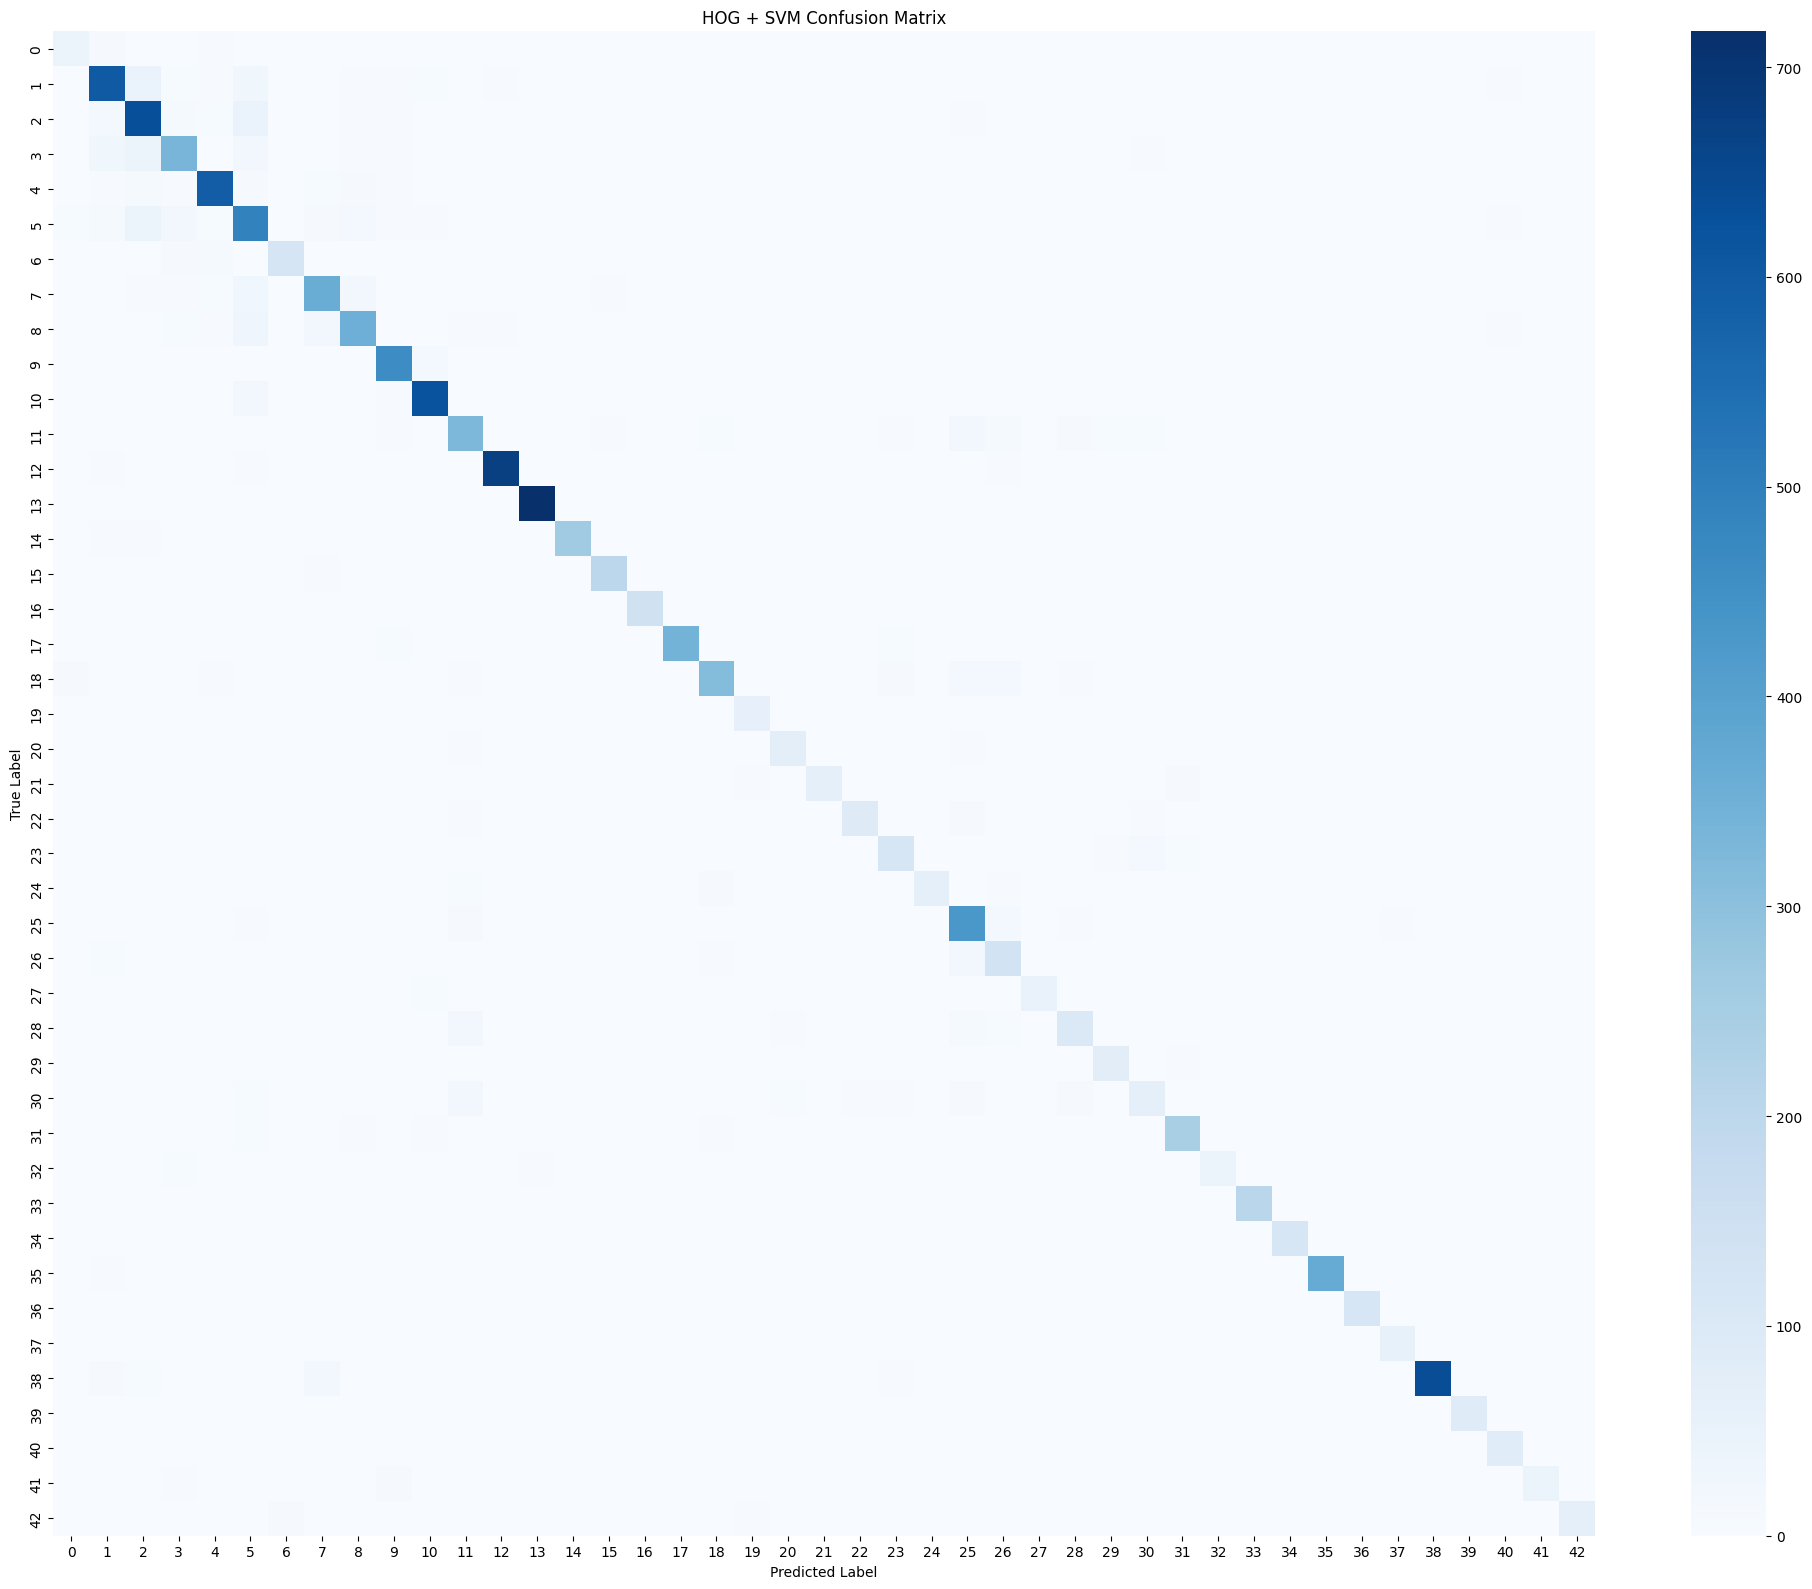

Confusion matrix saved!


In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(20, 16))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title('HOG + SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('hogsvm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")


In [7]:
# Save HOG+SVM results summary
hogsvm_results = {
    'model': 'HOG + LinearSVM',
    'test_accuracy': 87.17,
    'macro_f1': 0.86,
    'best_class': 'Class 13 - Speed limit 80 end (F1: 0.99)',
    'worst_class': 'Class 30 - Beware ice/snow (F1: 0.53)'
}

print("HOG + SVM Results Summary")
print("="*40)
for key, value in hogsvm_results.items():
    print(f"{key}: {value}")
print("="*40)
print("Baseline established! Deep learning models should beat 87.17%")

HOG + SVM Results Summary
model: HOG + LinearSVM
test_accuracy: 87.17
macro_f1: 0.86
best_class: Class 13 - Speed limit 80 end (F1: 0.99)
worst_class: Class 30 - Beware ice/snow (F1: 0.53)
Baseline established! Deep learning models should beat 87.17%
